In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import pandas as pd

In [2]:
def diagonal(ax):
    ax.set_aspect('equal')
    ax.plot([0,1], [0,1], lw=0.5, c='k')


def dense_scatter(naive, learnt):
    xy = np.vstack([naive, learnt])
    z = st.gaussian_kde(xy)(xy)
    plt.scatter(*xy, c=z, s=20)
    diagonal()
    plt.xlabel('naive')
    plt.ylabel('learnt')
    print(f'naive: mean={np.mean(naive)}, success={np.count_nonzero(naive)/len(naive)}')
    print(f'learnt: mean={np.mean(learnt)}, sucsess={np.count_nonzero(learnt)/len(learnt)}')
    print(st.ttest_rel(naive, learnt, alternative='two-sided'))

def learnt_vs_naive(dataframe, ax, ax_title, condition=None):
    df = dataframe[:] if condition is None else dataframe[condition]
    df.plot.scatter(x='BugMBCXnaive', y='BugMBCXlearnt', s=5, ax=ax)
    diagonal(ax)
    t_stat, p_val = st.ttest_rel(df['BugMBCXlearnt'], df['BugMBCXnaive'])
    ax.set_title(f'{ax_title}\n t-test(learnt-naive)\n t={t_stat:.3f}, p={p_val:.3f}')

In [3]:
data = {}
# data_dir = "/home/yihelu/habitat-insect/examples/newtransfersoftspl50" # the performance is almost identical to spl # 0.55/0.86
model_data_dir = "/home/yihelu/habitat-insect/examples/newtransferspl50" # 0.6/0.9
other_data_dir = "/home/yihelu/habitat-insect/examples/newtransfer-halfturnangle" # 0.5/0.87 # contain other model data
for data_dir in [model_data_dir, other_data_dir]:
    for episode_idx in os.listdir(data_dir):
        episode_dir = os.path.join(data_dir, episode_idx)
        trial_files = [os.path.join(episode_dir, trial_file) for trial_file in os.listdir(episode_dir)]
        trial_files.sort(key=lambda x: os.path.getmtime(x))
        if trial_files[-1].endswith('_test9.json'):
            if episode_idx not in data.keys(): data[episode_idx] = {}
            if data_dir == model_data_dir:
                for trial_file in trial_files:
                    if 'BugMBCX' in trial_file:
                        # Open the JSON file
                        with open(trial_file, 'r') as file:
                            # Load the contents of the file into a dictionary
                            data[episode_idx][trial_file] = json.load(file)
            else:
                for trial_file in trial_files:
                    if 'BugMBCX' not in trial_file:
                        # Open the JSON file
                        with open(trial_file, 'r') as file:
                            # Load the contents of the file into a dictionary
                            data[episode_idx][trial_file] = json.load(file)

In [44]:
ls_train = {'spl': [], 'collision': [], 'scene': [], 'episode': [], 'trial': []}
ls_test = {'spl': [], 'collision': [], 'scene': [], 'episode': [], 'train-scene': [], 'train-episode': [], 'model': []}
ls_other = {'spl': [], 'collision': [], 'scene': [], 'episode': [], 'model': []}

for episode in data:
    train_scene, train_episode = episode.split('.glb_')
    for trial in data[episode]:
        data_trial = data[episode][trial]
        if 'BugMBCX' in trial:
            if '_train' in trial:
                ls_train['spl'].append(data_trial['spl'])
                ls_train['collision'].append(data_trial['collision_count'])
                ls_train['scene'].append(train_scene)
                ls_train['episode'].append(int(train_episode))
                ls_train['trial'].append(int(data_trial['trial_name'].rsplit('n', maxsplit=1)[-1]))
            else:
                ls_test['spl'].append(data_trial['spl'])
                ls_test['collision'].append(data_trial['collision_count'])
                ls_test['train-scene'].append(train_scene)
                ls_test['train-episode'].append(int(train_episode))
                ls_test['scene'].append(data_trial['scene_id'].removesuffix('.glb'))
                ls_test['episode'].append(int(data_trial['episode_id']))
                ls_test['model'].append(data_trial['agent_name'])
        else:
            ls_other['spl'].append(data_trial['spl'])
            ls_other['collision'].append(data_trial['collision_count'])
            ls_other['scene'].append(data_trial['scene_id'].removesuffix('.glb'))
            ls_other['episode'].append(int(data_trial['episode_id']))
            ls_other['model'].append(data_trial['agent_name'])

def dictionary_to_dataframe(dataset, metric):
    # the order of the dataset index must be: 'spl', ..., 'trial'/'model'
    index_names = list(dataset.keys())[2:]
    multi_index = pd.MultiIndex.from_arrays([dataset[key] for key in index_names], names=index_names)
    df = pd.DataFrame(dataset[metric], index=multi_index)
    df = df[~df.index.duplicated()].unstack(level=index_names[-1]).sort_index(axis=1)
    df.columns = df.columns.droplevel(level=0)
    return df

In [45]:
df_train = dictionary_to_dataframe(ls_train, 'spl')
df_test = dictionary_to_dataframe(ls_test, 'spl')
df_other = dictionary_to_dataframe(ls_other, 'spl')

In [46]:
col_train = dictionary_to_dataframe(ls_train, 'collision')
col_test = dictionary_to_dataframe(ls_test, 'collision')
col_other = dictionary_to_dataframe(ls_other, 'collision')

In [56]:
best_trial = df_train.notna().sum(axis=1) - 2
best_trial[best_trial < 0] = 0
spl_learnt = df_train.values[np.arange(df_train.shape[0]), best_trial]
col_learnt = col_train.values[np.arange(df_train.shape[0]), best_trial]

In [109]:
model_names = 'PI-only', 'PI+escape', 'Full-first', 'Full-learnt'

data4comparison = {'spl': {}, 'collision': {}}

data4comparison['spl']['Full-first'] = df_train[0].values.tolist()
data4comparison['spl']['Full-learnt'] = spl_learnt.tolist()
data4comparison['collision']['Full-first'] = col_train[0].values.tolist()
data4comparison['collision']['Full-learnt'] = col_learnt.tolist()

for model, key in zip(model_names[:2], ['GoalFollower', 'BugCX']):
    data4comparison['spl'][model] = df_other[key][df_train.index].values.tolist()
    data4comparison['collision'][model] = col_other[key][df_train.index].values.tolist()

with open("model4newhabitat.json", "w") as outfile:
    json.dump(data4comparison, outfile)

In [55]:
print(f'learnt {df_train[0].mean():.6f}, {(df_train[0] > 0).mean():.6f}')
print(f'learnt {spl_learnt.mean():.6f}, {(spl_learnt > 0).mean():.6f}')

learnt 0.532150, 0.860000
learnt 0.596381, 0.900000


In [9]:
df_other.mean(), (df_other > 0).mean()

learntL 0.596381, 0.900000


(model
 BugCX                        0.386230
 GoalFollower                 0.195237
 ShortestPathFollowerAgent    0.997771
 dtype: float64,
 model
 BugCX                        0.611670
 GoalFollower                 0.200201
 ShortestPathFollowerAgent    0.998994
 dtype: float64,
 None)

In [10]:
max_train = df_train.notna().sum(axis=1).max(axis=0)

<Axes: >

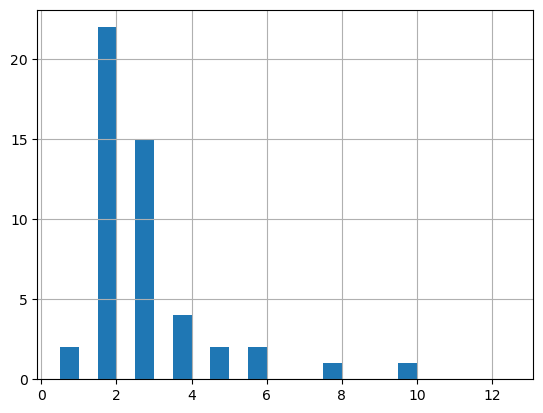

In [11]:
df_train.notna().sum(axis=1).hist(bins=np.arange(0.5, max_train + 0.1, 1),
                                 width=0.5
                                 )

model
BugMBCXlearnt    0.44475
BugMBCXnaive     0.44701
dtype: float64 model
BugMBCXlearnt    0.800
BugMBCXnaive     0.804
dtype: float64


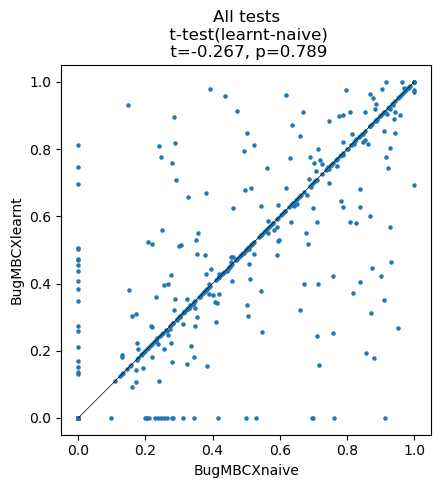

In [12]:
fig, axes = plt.subplots()
learnt_vs_naive(df_test, axes, 'All tests')
print(df_test.mean(), (df_test > 0).astype(int).mean())

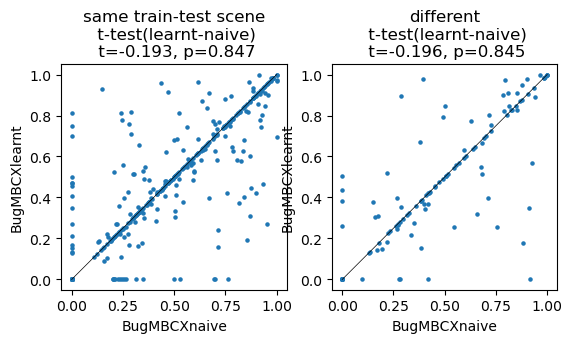

In [13]:
fig, axes = plt.subplots(1, 2)
positive = df_test.index.get_level_values('train-scene') == df_test.index.get_level_values('scene')
for condition, tit, ax in zip([positive, np.logical_not(positive)], ['same train-test scene', 'different'], axes):
    learnt_vs_naive(df_test, ax, tit, condition)

In [14]:
df_test.index.unique('train-scene').shape

(14,)

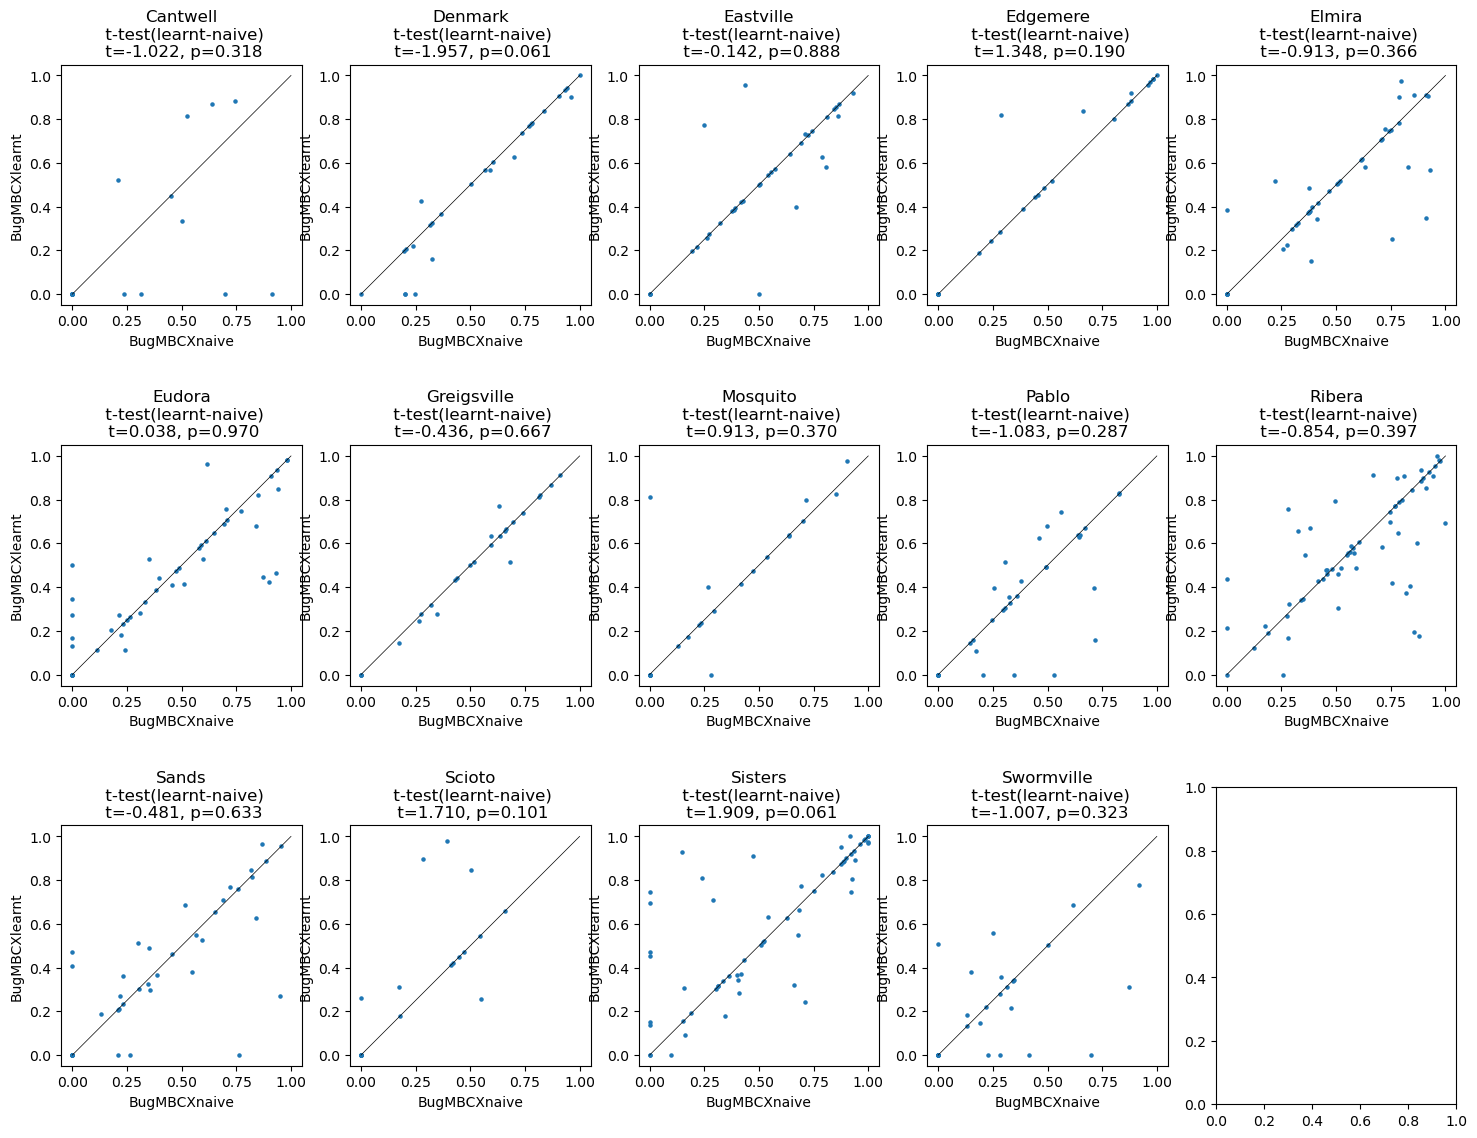

In [15]:
fig, axes = plt.subplots(3, 5, figsize=(18, 14))
for scene, ax in zip(df_test.index.unique('scene'), axes.flatten()):
    condition = df_test.index.get_level_values(level='scene') == scene
    learnt_vs_naive(df_test, ax, scene, condition)

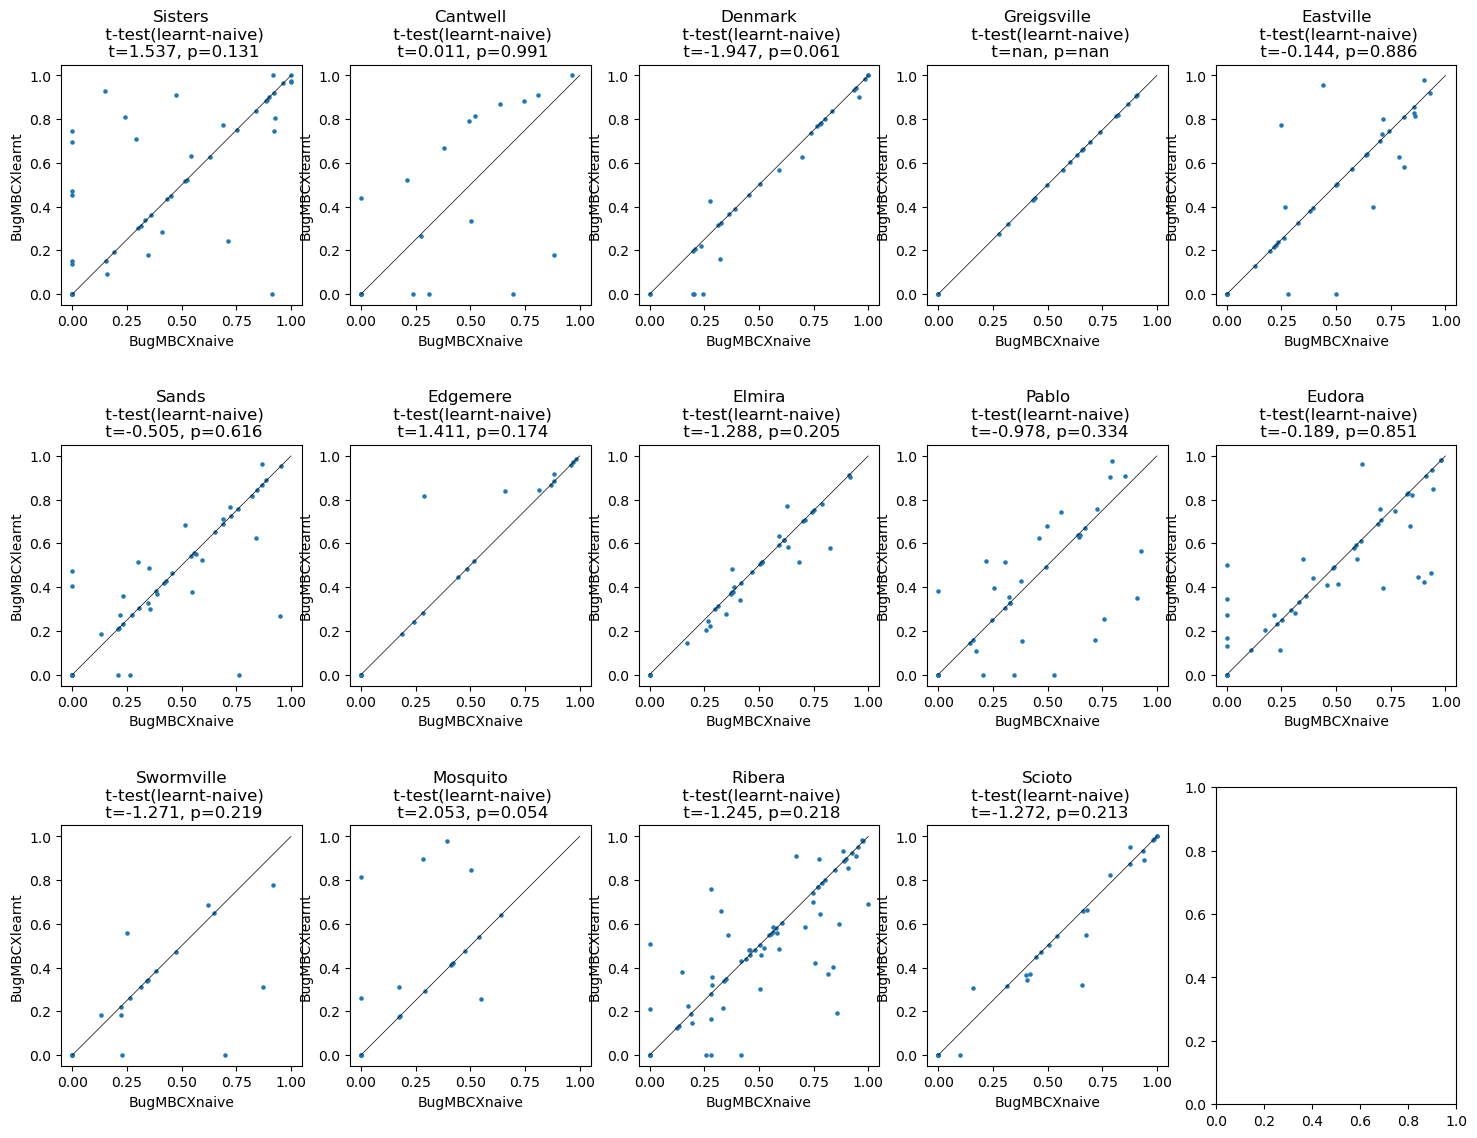

In [16]:
fig, axes = plt.subplots(3, 5, figsize=(18, 14))
for scene, ax in zip(df_test.index.unique('train-scene'), axes.flatten()):
    condition = df_test.index.get_level_values(level='train-scene') == scene
    learnt_vs_naive(df_test, ax, scene, condition)